# Data cleaning: Beer Profile

This notebook aims to clean the dataset of beer profile. We will check different angles of the dataset. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


## 1. Check if there are missing values: 

In [9]:
df = pd.read_csv("beer_profile_and_ratings.csv")
df.isnull().values.any()


False

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               3197 non-null   object 
 1   Style              3197 non-null   object 
 2   Brewery            3197 non-null   object 
 3   Beer Name (Full)   3197 non-null   object 
 4   Description        3197 non-null   object 
 5   ABV                3197 non-null   float64
 6   Min IBU            3197 non-null   int64  
 7   Max IBU            3197 non-null   int64  
 8   Astringency        3197 non-null   int64  
 9   Body               3197 non-null   int64  
 10  Alcohol            3197 non-null   int64  
 11  Bitter             3197 non-null   int64  
 12  Sweet              3197 non-null   int64  
 13  Sour               3197 non-null   int64  
 14  Salty              3197 non-null   int64  
 15  Fruits             3197 non-null   int64  
 16  Hoppy              3197 

No missing values in the dataset, all columns have 3197 elements. Next we will check the scale of the dataset. 

## 2. Scaling for the dataset:

In the dataset, we don't need to encode the caracteristic variables because the features are all numerical variables. We will seperate the columns as:
| Category | Column Names |
| :--- | :--- |
| **Specifications** | `ABV`, `Min IBU`, `Max IBU` |
| **Profile Intensity** | `Astringency`, `Body`, `Alcohol` (Mouthfeel); `Bitter`, `Sweet`, `Sour`, `Salty` (Taste); `Fruits`, `Hoppy`, `Spices`, `Malty` (Flavor) |
| **User Ratings** | `review_aroma`, `review_appearance`, `review_palate`, `review_taste`, `review_overall` |
| **Volume Metrics** | `number_of_reviews` |

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

### a. Specifications:

In [14]:
specific_cols = ['ABV', 'Min IBU', 'Max IBU']
df_spec = df[specific_cols]
df_spec.describe().round(2)

,ABV,Min IBU,Max IBU
count,3197.00,3197.00,3197.00
mean,6.53,21.18,38.99
std,2.55,13.24,21.36
min,0.00,0.00,0.00
25%,5.00,15.00,25.00
50%,6.00,20.00,35.00
75%,7.60,25.00,45.00
max,57.50,65.00,100.00


In [23]:
scaled_num = scaler.fit_transform(df_spec)
df_spec_scaled = pd.DataFrame(scaled_num, columns=specific_cols)
df_spec_scaled.head()

,ABV,Min IBU,Max IBU
0,-0.481696,0.28848,0.515791
1,0.264397,0.28848,0.515791
2,-0.599501,0.28848,0.515791
3,0.774882,0.28848,0.515791
4,0.264397,0.28848,0.515791


- **ABV:**  Alcohol content by volume (%) 
- **Min IBU:**  Minimum IBU value for the specific beer style 
- **Max IBU:**  Maximum IBU value for the specific beer style 

These 3 specifications have range 0 to 100. ABV has smaller std, the other 2 are bigger. We gotta scale the these features. 

### b.Profile 

In [15]:
profile_features = [
    'Astringency', 'Body', 'Alcohol',           # Mouthfeel
    'Bitter', 'Sweet', 'Sour', 'Salty',         # Taste
    'Fruits', 'Hoppy', 'Spices', 'Malty'        # Flavor/Aroma
]

df_profile = df[profile_features]
df_profile.describe().round(2)

,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
count,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00,3197.00
mean,16.52,46.13,17.06,36.36,58.27,33.15,1.02,38.53,40.92,18.35,75.33
std,10.41,25.95,17.33,25.79,34.28,35.78,2.13,32.30,30.40,23.76,39.91
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.00,29.00,6.00,17.00,33.00,11.00,0.00,12.00,18.00,4.00,45.00
50%,14.00,40.00,11.00,31.00,54.00,22.00,0.00,29.00,33.00,10.00,73.00
75%,21.00,58.00,22.00,52.00,77.00,42.00,1.00,60.00,56.00,23.00,103.00
max,81.00,175.00,139.00,150.00,263.00,284.00,48.00,175.00,172.00,184.00,239.00


The profiles of beers have quite different range of value. We need to scale this part to let them into a similar range, and reduce the impact of some features.

In [ ]:
scaled_num = scaler.fit_transform(df_profile)
df_profile_scaled = pd.DataFrame(scaled_num, columns=profile_features)
df_profile_scaled.head()

,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,-0.337764,-0.544620,-0.464895,0.412438,0.458897,-0.004066,-0.477041,-0.171238,0.528815,-0.435553,0.893892
1,-0.433834,0.419002,0.054477,-0.130468,-0.095428,-0.479264,-0.477041,-0.449949,-0.194896,-0.267152,0.217253
2,-0.241694,-0.351895,-0.638019,0.218543,-0.445528,-0.619028,-0.477041,-0.883498,0.430127,-0.603954,-0.334083
3,-0.337764,0.341912,0.804681,0.412438,1.246621,-0.423358,-0.008068,0.324247,-0.030416,-0.098752,1.094378
4,0.815081,0.187733,0.516141,0.296101,-0.387178,-0.674933,-0.008068,-0.852530,0.331439,0.069649,0.492921


We may find some connections between the taste by pairplots:

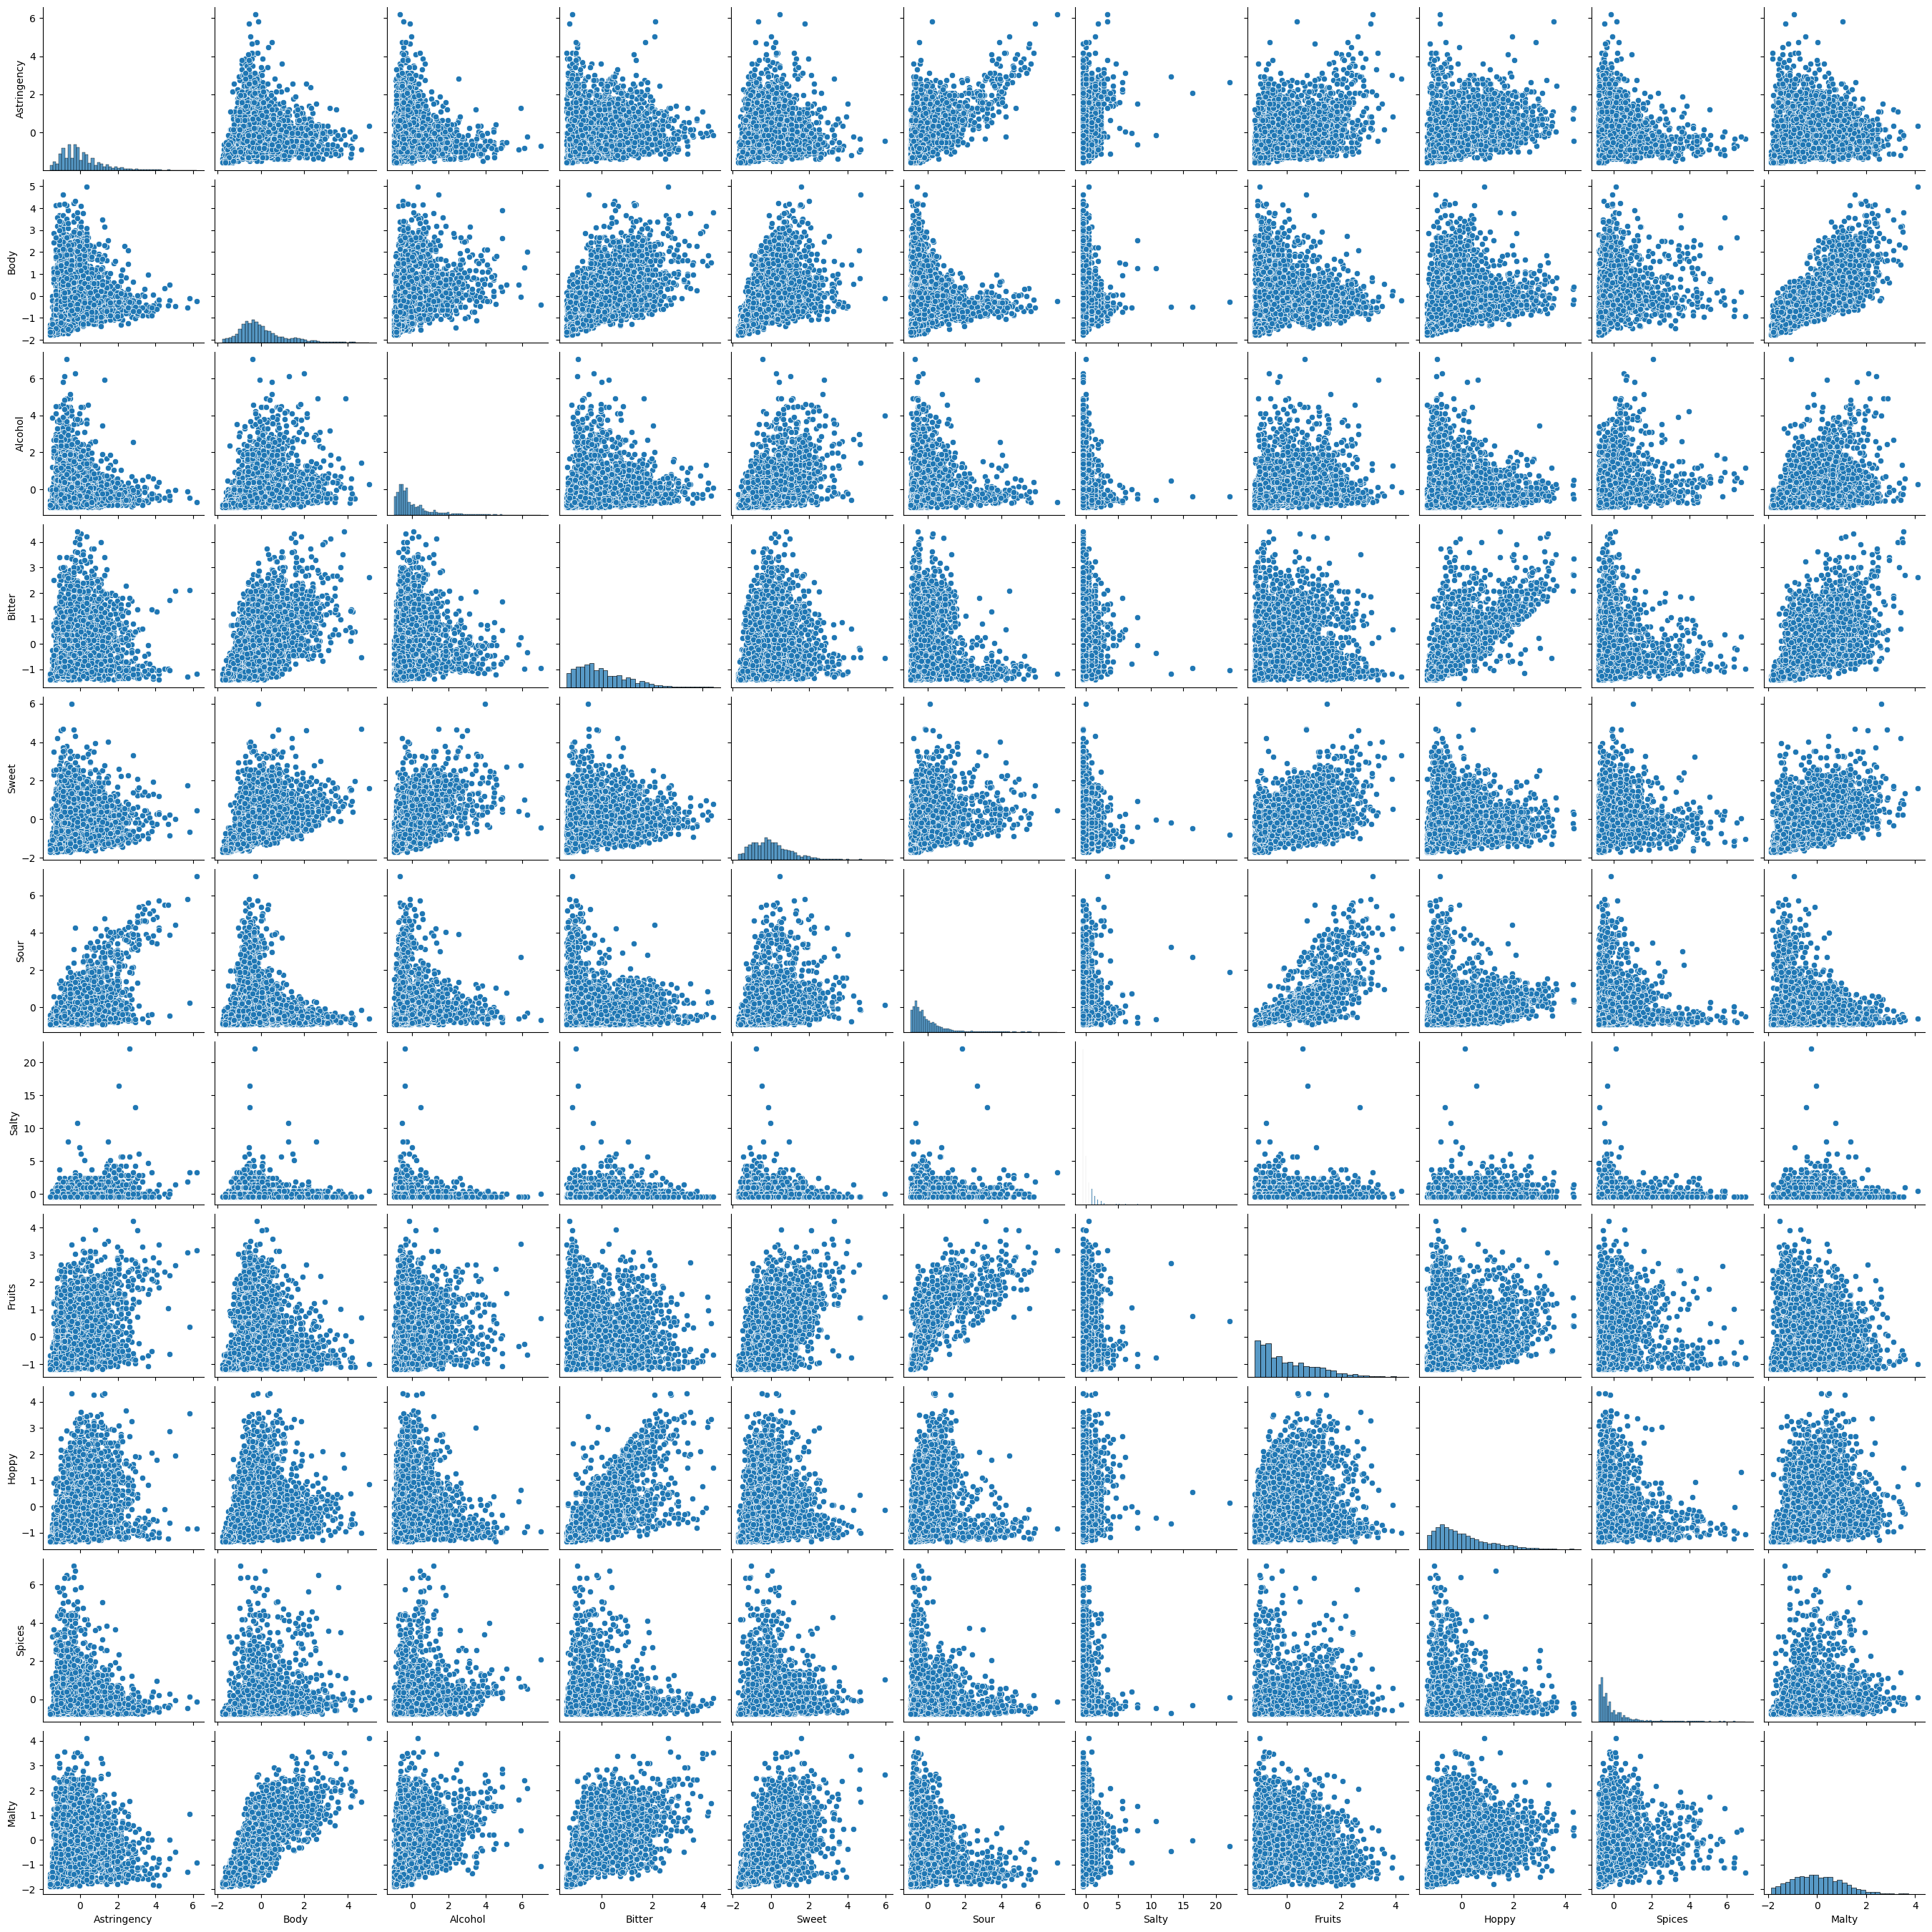

In [19]:
sns.pairplot(df_profile_scaled)
plt.show()

### c.Ratings
The last part is user's ratings and the number of critics. We may not use the number of critics, so we don't do scaling on it.

In [20]:
rating_features = [
    'review_aroma', 'review_appearance', 'review_palate', 
    'review_taste', 'review_overall'
]
df_rating = df[rating_features]
df_rating.describe().round(2)

,review_aroma,review_appearance,review_palate,review_taste,review_overall
count,3197.00,3197.00,3197.00,3197.00,3197.00
mean,3.64,3.75,3.66,3.70,3.75
std,0.50,0.40,0.45,0.51,0.44
min,1.51,1.57,1.29,1.21,1.14
25%,3.42,3.60,3.47,3.50,3.57
50%,3.72,3.83,3.74,3.79,3.83
75%,3.98,4.00,3.97,4.03,4.03
max,5.00,4.67,5.00,5.00,5.00


The range of ratings are from 1 to 5. If we want to do the clustering on ratings, we don't need to scale them. 

In [24]:
volume_features = ['number_of_reviews']
df[volume_features].describe().round(2)

,number_of_reviews
count,3197.00
mean,233.28
std,361.81
min,1.00
25%,23.00
50%,93.00
75%,284.00
max,3290.00


## Conclusion:

We finally use the dataset with scaling specification and profile data. 

In [31]:
df[specific_cols] = df_spec_scaled[specific_cols]
df[profile_features] = df_profile_scaled[profile_features]

df.to_csv('cleaned_Beer_data.csv', index=False, encoding='utf-8-sig')